In [1]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
import operator
from langgraph.checkpoint.memory import MemorySaver


In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.2,
)

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    # messages: Annotated[list[BaseMessage], operator.add]
    # or
    messages: Annotated[list[BaseMessage], add_messages]
    
    


In [5]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [6]:
checkpointer= MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# chatbot = graph.compile()
chatbot = graph.compile(checkpointer=checkpointer)


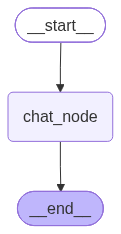

In [7]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage(content='What is captial of india')]
}

# chatbot.invoke(initial_state)
# chatbot.invoke(initial_state)['messages'][-1].content

In [9]:
thread_id= 1
while True:
    user_message = input('Type here: ')
    print(user_message)
    if user_message.lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable':{'thread_id':thread_id}}

    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]},config=config)
    print("AI:", response['messages'][-1].content[0]["text"])

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


hi i am raj
AI: Hi Raj! Nice to meet you. How can I help you today?
what is my name


c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


AI: Your name is Raj! You just told me in your first message.
exit


In [10]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi i am raj', additional_kwargs={}, response_metadata={}, id='8e1e62ae-aa55-4dd0-bc7c-79c209ba9f12'), AIMessage(content=[{'type': 'text', 'text': 'Hi Raj! Nice to meet you. How can I help you today?', 'extras': {'signature': 'El4KXAERTTIP1OOuZFcnWpBcJZphKVrHxepeXk2c00+uUmyHbvAxS0F25+70tB6MB54AMBlq9q/UU34x0QNk40ejBsU0DLXwZ/OTVKLFJZJCXvUUDZiJ1Q76iMgCsRgB'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a09b60-9fb1-78a2-b5a0-d0c8ca0fe9e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 15, 'total_tokens': 20, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='a3b24bfc-8aa3-4fe3-8063-dcd7159bc303'), AIMessage(content=[{'type': 'text', 'text': 'Your name is Raj! You just told me in